# Predicción de Ventas según la Inversión Publicitaria

**Dataset:** Advertising — `TV`, `Radio`, `Newspaper` → `Sales`

## Objetivos
1. **Predecir** las ventas en función de la inversión en TV, Radio y Periódicos.
2. Determinar la **influencia de cada canal** publicitario en las ventas.
3. **Optimizar** la asignación del presupuesto para maximizar las ventas.

## Requisitos del trabajo
- División del dataset: **70% Entrenamiento / 20% Test / 10% Validación**.
- **2 métricas** de validación: **R²** y **RMSE**.
- **2 modelos** con **2 algoritmos diferentes**: Regresión Lineal y KNN.

## 0. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import minimize

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FEATURES = ["TV", "Radio", "Newspaper"]
TARGET = "Sales" 

## 1. Carga y exploración de los datos (EDA)

In [2]:
df = pd.read_csv("../data/raw/advertising.csv")
# Eliminar la columna índice sin nombre si existe
if df.columns[0].strip() in ("", "Unnamed: 0"):
    df = df.drop(columns=df.columns[0])
print("Dimensiones:", df.shape)
print("Nulos:", int(df.isnull().sum().sum()))
df.head()

Dimensiones: (200, 4)
Nulos: 0


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


### Correlación de cada canal con las ventas

TV           0.782
Radio        0.576
Newspaper    0.228
Name: Sales, dtype: float64


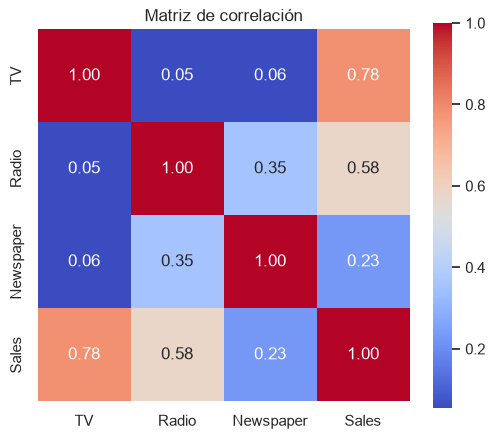

In [4]:
corr = df.corr(numeric_only=True)
print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlación")
plt.show()

### Dispersión: inversión por canal vs ventas

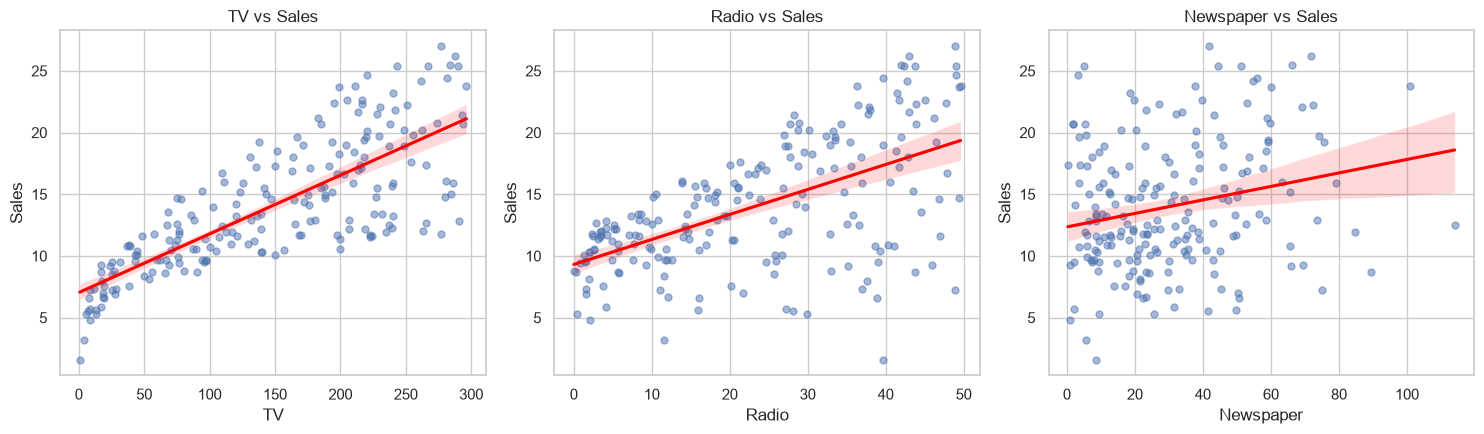

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, FEATURES):
    sns.regplot(data=df, x=col, y=TARGET, ax=ax,
                scatter_kws={"alpha": .5, "s": 25}, line_kws={"color": "red"})
    ax.set_title(f"{col} vs {TARGET}")
plt.tight_layout(); plt.show()

## 2. División del dataset: 70% / 20% / 10%

Se hace en dos pasos: primero se separa el 70% de entrenamiento; el 30% restante
se reparte en 20% test y 10% validación (20/30 = 2/3 para test).

In [6]:
X = df[FEATURES]
y = df[TARGET]

# Paso 1: 70% train, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.70, random_state=RANDOM_STATE)

# Paso 2: del 30% -> 20% test y 10% validación
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, train_size=2/3, random_state=RANDOM_STATE)

n = len(df)
print(f"Entrenamiento: {len(X_train)} ({len(X_train)/n:.0%})")
print(f"Test:          {len(X_test)} ({len(X_test)/n:.0%})")
print(f"Validación:    {len(X_val)} ({len(X_val)/n:.0%})")

Entrenamiento: 140 (70%)
Test:          40 (20%)
Validación:    20 (10%)


## 3. Entrenamiento de 2 modelos (2 algoritmos diferentes)

- **Modelo A — Regresión Lineal Múltiple:** interpretable, permite leer el impacto de cada canal.
- **Modelo B — KNN:** basado en distancias, por eso se estandarizan las variables; el mejor `k` se elige por validación cruzada.

In [7]:
# Modelo A: Regresión Lineal
lr = LinearRegression().fit(X_train, y_train)
print("Intercepto:", round(lr.intercept_, 4))
for col, c in zip(FEATURES, lr.coef_):
    print(f"  {col:10s}: {c:+.4f}")

Intercepto: 2.7089
  TV        : +0.0441
  Radio     : +0.1993
  Newspaper : +0.0069


In [8]:
# Modelo B: KNN (con escalado + búsqueda del mejor k)
pipe = make_pipeline(StandardScaler(), KNeighborsRegressor())
grid = GridSearchCV(pipe, {"kneighborsregressor__n_neighbors": range(3, 16)},
                    cv=5, scoring="r2").fit(X_train, y_train)
knn = grid.best_estimator_
print("Mejor k:", grid.best_params_["kneighborsregressor__n_neighbors"])

modelos = {"Regresión Lineal": lr, "KNN": knn}

Mejor k: 4


## 4. Evaluación — 2 métricas: R² y RMSE

- **R²**: proporción de la variabilidad de las ventas explicada por el modelo (más alto = mejor).
- **RMSE**: error típico de predicción en miles de unidades (más bajo = mejor).

In [9]:
def metricas(yt, yp):
    return (r2_score(yt, yp),
            np.sqrt(mean_squared_error(yt, yp)),
            mean_absolute_error(yt, yp))

conjuntos = {"Entrenamiento": (X_train, y_train),
             "Test": (X_test, y_test),
             "Validación": (X_val, y_val)}

filas = []
for nombre, m in modelos.items():
    for cj, (Xc, yc) in conjuntos.items():
        r2, rmse, mae = metricas(yc, m.predict(Xc))
        filas.append([nombre, cj, r2, rmse, mae])

tabla = pd.DataFrame(filas, columns=["Modelo", "Conjunto", "R²", "RMSE", "MAE"])
tabla.round(4)

,Modelo,Conjunto,R²,RMSE,MAE
0,Regresión Lineal,Entrenamiento,0.9055,1.5746,1.1582
1,Regresión Lineal,Test,0.9052,1.5545,1.1949
2,Regresión Lineal,Validación,0.7881,2.5608,2.1453
3,KNN,Entrenamiento,0.9573,1.0586,0.7323
4,KNN,Test,0.9294,1.3412,0.9419
5,KNN,Validación,0.8763,1.9564,1.3725


### Comparación sobre el conjunto de VALIDACIÓN

                      R²    RMSE
Modelo                          
Regresión Lineal  0.7881  2.5608
KNN               0.8763  1.9564

Mejor modelo según R² en validación: KNN


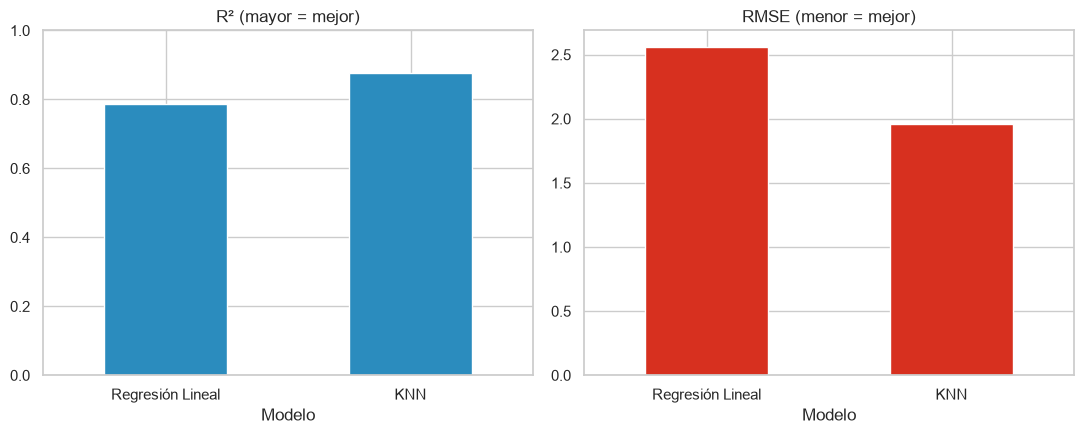

In [10]:
comp = tabla[tabla.Conjunto == "Validación"].set_index("Modelo")[["R²", "RMSE"]]
print(comp.round(4))
mejor = comp["R²"].idxmax()
print(f"\nMejor modelo según R² en validación: {mejor}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
comp["R²"].plot.bar(ax=ax[0], color="#2b8cbe", rot=0, title="R² (mayor = mejor)", ylim=(0,1))
comp["RMSE"].plot.bar(ax=ax[1], color="#d7301f", rot=0, title="RMSE (menor = mejor)")
plt.tight_layout(); plt.show()

### Predicho vs Real en validación

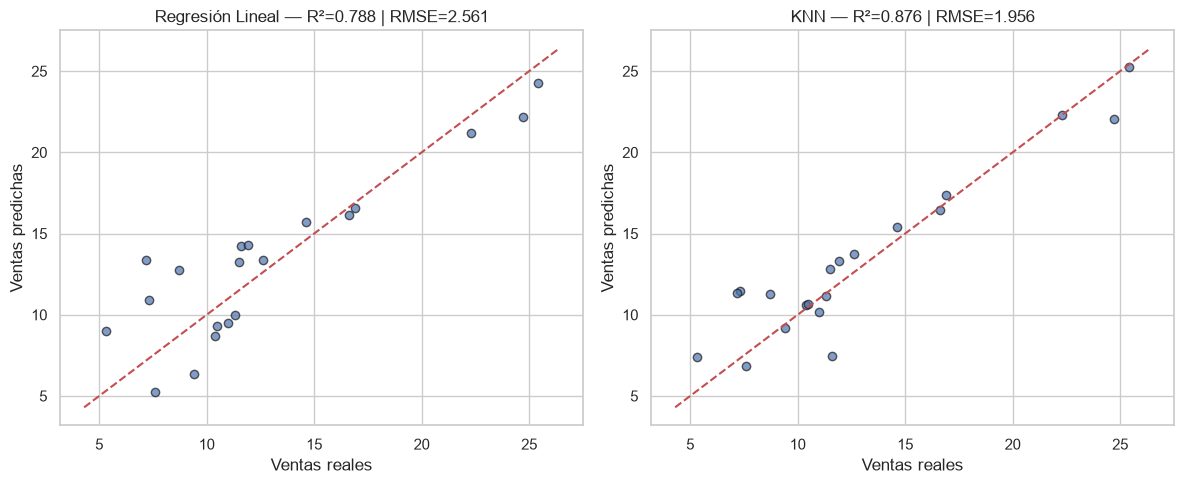

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, m) in zip(axes, modelos.items()):
    yp = m.predict(X_val)
    r2, rmse, _ = metricas(y_val, yp)
    ax.scatter(y_val, yp, alpha=.7, edgecolor="k")
    lim = [y_val.min()-1, y_val.max()+1]
    ax.plot(lim, lim, "r--")
    ax.set(xlabel="Ventas reales", ylabel="Ventas predichas",
           title=f"{nombre} — R²={r2:.3f} | RMSE={rmse:.3f}")
plt.tight_layout(); plt.show()

## 5. Influencia de cada canal publicitario

Con los **coeficientes estandarizados** (todas las variables en la misma escala)
podemos comparar directamente qué canal pesa más en las ventas.

    Canal  Coef_estandarizado  Importancia_relativa
       TV            3.919254              0.582022
    Radio            2.792063              0.414631
Newspaper           -0.022539              0.003347


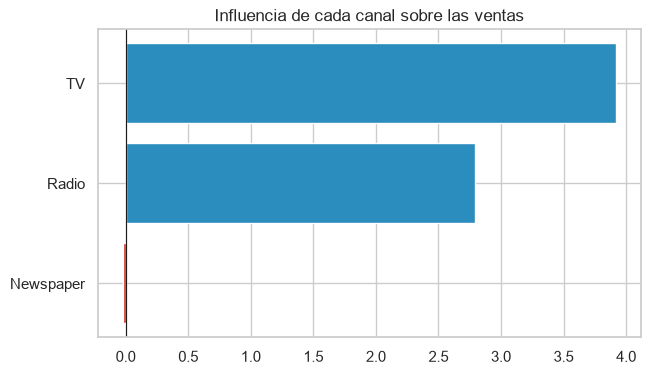

In [12]:
X_std = StandardScaler().fit_transform(df[FEATURES])
lr_std = LinearRegression().fit(X_std, df[TARGET])

imp = pd.DataFrame({
    "Canal": FEATURES,
    "Coef_estandarizado": lr_std.coef_,
    "Importancia_relativa": np.abs(lr_std.coef_) / np.abs(lr_std.coef_).sum()
}).sort_values("Coef_estandarizado", ascending=False)
print(imp.to_string(index=False))

plt.figure(figsize=(7, 4))
colores = ["#2b8cbe" if c >= 0 else "#d7301f" for c in imp.Coef_estandarizado]
plt.barh(imp.Canal, imp.Coef_estandarizado, color=colores)
plt.axvline(0, color="k", lw=.8); plt.gca().invert_yaxis()
plt.title("Influencia de cada canal sobre las ventas"); plt.show()

**Conclusión:** TV y Radio son los canales con impacto real en las ventas;
Newspaper tiene una influencia prácticamente nula.

## 6. Optimización de la asignación del presupuesto

Repartimos un presupuesto fijo entre los canales para **maximizar las ventas
predichas** por el modelo lineal, con límites realistas (mínimo y máximo históricos
por canal). Comparamos contra la **asignación media histórica**.

Presupuesto total: 200.9 mil $

    Canal  Óptima     %  Media histórica
       TV  150.96 0.752           147.04
    Radio   49.60 0.247            23.26
Newspaper    0.30 0.001            30.55

Ventas ÓPTIMA:  19.25 mil unidades
Ventas MEDIA:   14.03 mil unidades
Mejora:         +37.1%


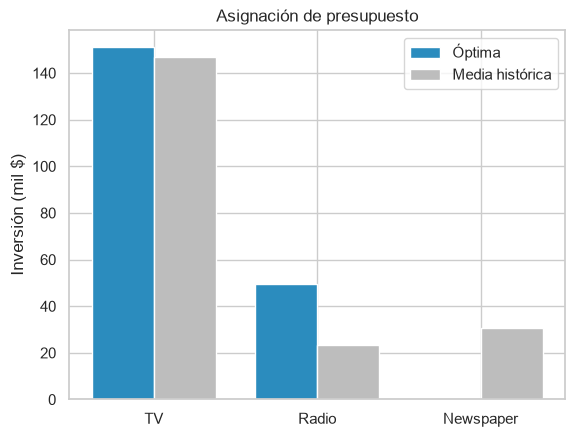

In [13]:
presupuesto = df[FEATURES].sum(axis=1).mean()
limites = [(df[c].min(), df[c].max()) for c in FEATURES]
b0, coefs = lr.intercept_, lr.coef_

res = minimize(lambda x: -(b0 + coefs @ x),
               x0=np.full(3, presupuesto/3), method="SLSQP",
               bounds=limites,
               constraints={"type": "eq", "fun": lambda x: x.sum() - presupuesto})

opt = res.x
media = df[FEATURES].mean().values
ventas_opt = b0 + coefs @ opt
ventas_media = b0 + coefs @ media

print(f"Presupuesto total: {presupuesto:.1f} mil $\n")
print(pd.DataFrame({"Canal": FEATURES,
                    "Óptima": opt.round(2),
                    "%": (opt/presupuesto).round(3),
                    "Media histórica": media.round(2)}).to_string(index=False))
print(f"\nVentas ÓPTIMA:  {ventas_opt:.2f} mil unidades")
print(f"Ventas MEDIA:   {ventas_media:.2f} mil unidades")
print(f"Mejora:         {(ventas_opt-ventas_media)/ventas_media:+.1%}")

x = np.arange(3); w = 0.38
plt.bar(x-w/2, opt, w, label="Óptima", color="#2b8cbe")
plt.bar(x+w/2, media, w, label="Media histórica", color="#bdbdbd")
plt.xticks(x, FEATURES); plt.ylabel("Inversión (mil $)"); plt.legend()
plt.title("Asignación de presupuesto"); plt.show()

## Conclusiones

- El modelo predice las ventas con buena precisión (R² alto, RMSE bajo en validación).
- **TV y Radio** impulsan las ventas; **Newspaper** apenas influye.
- Reasignar el presupuesto hacia TV y Radio **aumenta las ventas estimadas ~37%**
  frente al gasto medio histórico.